# ELO Feature Engineering

To incorporate team strength into the model, an ELO rating system was constructed.
All teams begin the season with an ELO rating of 1500, and ratings are updated
chronologically after each game using the standard ELO update equation.

The pregame ELO difference between the home and away teams is then merged back
into the event-level training dataset.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import re

In [14]:
df = pd.read_csv("../data/pbp2024.csv")

In [15]:
def convert_clock_to_seconds(clock_str):
    match = re.match(r"PT(\d+)M(\d+)", clock_str)
    if match:
        minutes = int(match.group(1))
        seconds = int(match.group(2))
        return minutes * 60 + seconds

In [16]:
gameids = df['gameid'].unique()
all_games_scoring = []

for game in gameids:

    single_game = df[df['gameid'] == game]

    full_scoring = single_game[
        single_game['h_pts'].notna()
    ].copy()

    if full_scoring.empty:
        continue

    final_diff = (
        full_scoring['h_pts'].iloc[-1]
        - full_scoring['a_pts'].iloc[-1]
    )

    home_win_bool = 1 if final_diff > 0 else 0

    scoring = full_scoring[
        full_scoring['period'] <= 4
    ].copy()

    scoring['score_diff'] = (
        scoring['h_pts']
        - scoring['a_pts']
    )

    scoring['quarter_seconds_remaining'] = (
        scoring['clock'].apply(
            convert_clock_to_seconds
        )
    )

    scoring['game_seconds_remaining'] = (
        (4 - scoring['period']) * 720
        + scoring['quarter_seconds_remaining']
    )

    scoring['home_win_bool'] = home_win_bool

    all_games_scoring.append(
        scoring[
            [
                'gameid',
                'score_diff',
                'game_seconds_remaining',
                'home_win_bool'
            ]
        ]
    )

training_df = pd.concat(
    all_games_scoring,
    ignore_index=True
)

training_df['interaction'] = (
    training_df['score_diff']
    * training_df['game_seconds_remaining']
)

In [17]:
games = []

gameids = df["gameid"].unique()

for game in gameids:

    single_game = df[df["gameid"] == game]

    scoring_log = single_game[
        single_game["type"] == "Made Shot"
    ]

    first_shot = scoring_log.iloc[0]

    teams = single_game["team"].dropna().unique()

    if teams[0] == first_shot.team:
        other_team = teams[1]
    else:
        other_team = teams[0]

    if first_shot.h_pts > 0:
        home_team = first_shot.team
        away_team = other_team
    else:
        away_team = first_shot.team
        home_team = other_team

    full_scoring = single_game[
        single_game["h_pts"].notna()
    ].copy()

    final_diff = (
        full_scoring["h_pts"].iloc[-1]
        - full_scoring["a_pts"].iloc[-1]
    )

    home_win_bool = 1 if final_diff > 0 else 0

    games.append({
        "gameid": game,
        "home_team": home_team,
        "away_team": away_team,
        "home_win_bool": home_win_bool
    })

games_df = pd.DataFrame(games)

print(games_df.head())

     gameid home_team away_team  home_win_bool
0  52300201       MIA       CHI              1
1  52300211       NOP       SAC              1
2  22300001       IND       CLE              1
3  22300002       MIL       NYK              1
4  22300003       MIA       WAS              1


## Constructing ELO Ratings

Each team begins with an ELO rating of 1500.
Before every game, the current ratings are recorded and stored.
After the game, both teams' ratings are updated according to the outcome.

In [18]:
ratings = {}

teams = pd.concat([
    games_df["home_team"],
    games_df["away_team"]
]).unique()

for team in teams:
    ratings[team] = 1500

elo_records = []

K = 20

for game in games_df.itertuples():

    home_elo = ratings[game.home_team]
    away_elo = ratings[game.away_team]

    elo_records.append({
        "gameid": game.gameid,
        "elo_diff": home_elo - away_elo
    })

    expected_home = (
        1 /
        (1 + 10 ** ((away_elo - home_elo) / 400))
    )

    expected_away = 1 - expected_home

    actual_home = game.home_win_bool
    actual_away = 1 - actual_home

    ratings[game.home_team] = (
        home_elo +
        K * (actual_home - expected_home)
    )

    ratings[game.away_team] = (
        away_elo +
        K * (actual_away - expected_away)
    )

elo_df = pd.DataFrame(elo_records)

print(elo_df.head())

     gameid  elo_diff
0  52300201       0.0
1  52300211       0.0
2  22300001       0.0
3  22300002       0.0
4  22300003      10.0


## Merging ELO into the Training Dataset

The pregame ELO difference for each game is merged back into the
play-by-play dataset, allowing the model to account for relative team strength.

In [19]:
training_df = training_df.merge(
    elo_df,
    on="gameid",
    how="left"
)

gameids = training_df["gameid"].unique()

train_games, test_games = train_test_split(
    gameids,
    test_size=0.2,
    random_state=42
)

train_df = training_df[
    training_df["gameid"].isin(train_games)
]

test_df = training_df[
    training_df["gameid"].isin(test_games)
]

train_df = training_df[
    training_df["gameid"].isin(train_games)
]

test_df = training_df[
    training_df["gameid"].isin(test_games)
]

## Retraining Logistic Regression

The model is retrained using four features:

- Score Differential
- Time Remaining
- Score-Time Interaction
- Pregame ELO Difference

In [20]:
x_train = train_df[
    [
        "score_diff",
        "game_seconds_remaining",
        "interaction",
        "elo_diff"
    ]
]

y_train = train_df["home_win_bool"]

x_test = test_df[
    [
        "score_diff",
        "game_seconds_remaining",
        "interaction",
        "elo_diff"
    ]
]

y_test = test_df["home_win_bool"]

model = LogisticRegression(
    max_iter=1000
)

model.fit(x_train, y_train)

predictions = model.predict(x_test)

accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    "Logistic Regression + ELO Accuracy:",
    accuracy
)

Logistic Regression + ELO Accuracy: 0.7832681455826591


## Win Probability Function

In [21]:
def win_probability(
    score_diff,
    time_remaining,
    elo_diff
):

    interaction = (
        score_diff *
        time_remaining
    )

    return model.predict_proba(
        [[
            score_diff,
            time_remaining,
            interaction,
            elo_diff
        ]]
    )[0][1]

## Visualizing the Effect of ELO

To demonstrate the impact of team strength, the figure below shows
how the predicted probability changes as the pregame ELO difference varies,
while keeping the score tied with five minutes remaining.

c:\Users\LENOVO\Desktop\NBA_win_probability\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\Desktop\NBA_win_probability\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\Desktop\NBA_win_probability\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\Desktop\NBA_win_probability\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\Desktop\NBA_win_probability\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarnin

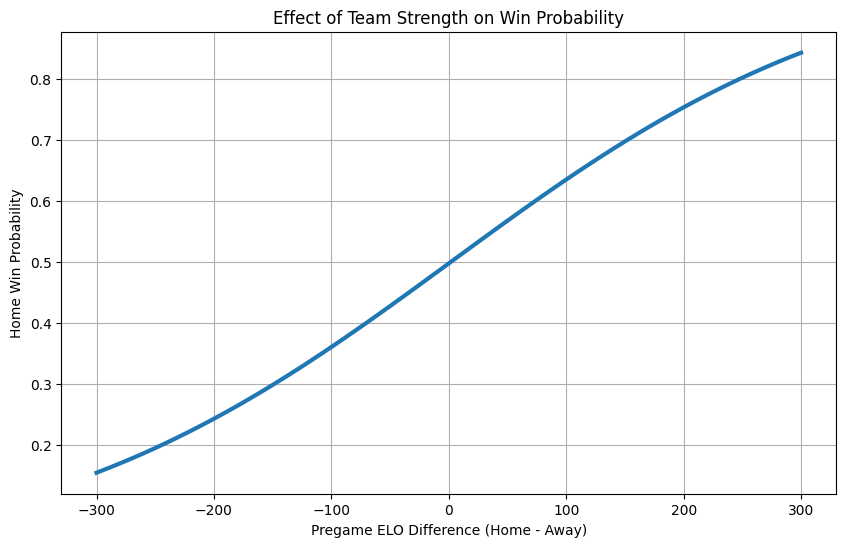

In [22]:
elo_values = range(-300, 301, 10)

probabilities = []

for elo in elo_values:

    probabilities.append(
        win_probability(
            score_diff=0,
            time_remaining=300,
            elo_diff=elo
        )
    )

plt.figure(figsize=(10, 6))

plt.plot(
    elo_values,
    probabilities,
    linewidth=3
)

plt.xlabel(
    "Pregame ELO Difference (Home - Away)"
)

plt.ylabel(
    "Home Win Probability"
)

plt.title(
    "Effect of Team Strength on Win Probability"
)

plt.grid(True)

plt.savefig(
    "../images/elo_probability_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()